<a href="https://colab.research.google.com/github/juandiegomadrigal576-droid/TALLER-MACHINE-LEARNING/blob/main/Entregable_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# APRENDIZAJE NO SUPERVISADO (Entregable 5)


# 1. Exploración de datos


In [58]:
# Importamos librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN, KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from google.colab import files

In [59]:
# Cargamos el dataset. No tiene encabezado, así que asignamos nombres de columna

uploaded = files.upload()

df1 = pd.read_csv(
    "steam-200k.csv",
    header=None,
    names=["user_id", "game", "behavior", "value", "extra"]
)
df1.head(10)

Saving steam-200k.csv to steam-200k (1).csv


,user_id,game,behavior,value,extra
0,151603712,The Elder Scrolls V Skyrim,purchase,1.0,0
1,151603712,The Elder Scrolls V Skyrim,play,273.0,0
2,151603712,Fallout 4,purchase,1.0,0
3,151603712,Fallout 4,play,87.0,0
4,151603712,Spore,purchase,1.0,0
5,151603712,Spore,play,14.9,0
6,151603712,Fallout New Vegas,purchase,1.0,0
7,151603712,Fallout New Vegas,play,12.1,0
8,151603712,Left 4 Dead 2,purchase,1.0,0
9,151603712,Left 4 Dead 2,play,8.9,0


In [60]:
# Dimensiones del dataset
print(f"Filas: {df1.shape[0]:,}")
print(f"Columnas: {df1.shape[1]}")

Filas: 200,000
Columnas: 5


In [61]:
# Tipos de variables
df1.dtypes

,0
user_id,int64
game,object
behavior,object
value,float64
extra,int64


In [62]:
# Generalidades de la tabla
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   user_id   200000 non-null  int64  
 1   game      200000 non-null  object 
 2   behavior  200000 non-null  object 
 3   value     200000 non-null  float64
 4   extra     200000 non-null  int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 7.6+ MB


In [63]:
# Valores nulos
df1.isnull().sum()

,0
user_id,0
game,0
behavior,0
value,0
extra,0


No hay valores nulos en ninguna columna.

In [64]:
# Registros duplicados
n_dup = df1.duplicated().sum()
print(f"Filas totalmente duplicadas: {n_dup}")
df1[df1.duplicated(keep=False)].sort_values(["user_id", "game"]).head(8)

Filas totalmente duplicadas: 707


,user_id,game,behavior,value,extra
142904,561758,Sid Meier's Civilization IV,purchase,1.0,0
142905,561758,Sid Meier's Civilization IV,purchase,1.0,0
142906,561758,Sid Meier's Civilization IV Beyond the Sword,purchase,1.0,0
142907,561758,Sid Meier's Civilization IV Beyond the Sword,purchase,1.0,0
142908,561758,Sid Meier's Civilization IV Colonization,purchase,1.0,0
142909,561758,Sid Meier's Civilization IV Colonization,purchase,1.0,0
142910,561758,Sid Meier's Civilization IV Warlords,purchase,1.0,0
142911,561758,Sid Meier's Civilization IV Warlords,purchase,1.0,0


Existen 707 filas exactamente duplicadas. No aportan información adicional y deben eliminarse para que no generen problemas después

In [65]:
# Estadísticos descriptivos generales
df1.describe(include="all")

,user_id,game,behavior,value,extra
count,2.000000e+05,200000,200000,200000.000000,200000.0
unique,NaN,5155,2,NaN,NaN
top,NaN,Dota 2,purchase,NaN,NaN
freq,NaN,9682,129511,NaN,NaN
mean,1.036559e+08,NaN,NaN,17.874384,0.0
std,7.208074e+07,NaN,NaN,138.056952,0.0
min,5.250000e+03,NaN,NaN,0.100000,0.0
25%,4.738420e+07,NaN,NaN,1.000000,0.0
50%,8.691201e+07,NaN,NaN,1.000000,0.0
75%,1.542309e+08,NaN,NaN,1.300000,0.0


In [66]:
# Esta columna no brinda información.
df1["extra"].value_counts()

,count
extra,
0,200000


In [67]:
print(df1["behavior"].value_counts())
print()
print(f"Usuarios únicos: {df1['user_id'].nunique():,}")
print(f"Juegos únicos:   {df1['game'].nunique():,}")

behavior
purchase    129511
play         70489
Name: count, dtype: int64

Usuarios únicos: 12,393
Juegos únicos:   5,155


In [68]:
df1.groupby("behavior")["value"].describe()

,count,mean,std,min,25%,50%,75%,max
behavior,,,,,,,,
play,70489.0,48.878063,229.335236,0.1,1.0,4.5,19.1,11754.0
purchase,129511.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0


Hay datos sumamente atípicos que tenderemos que abordar a continuación.

## Visualizaciones exploratorias

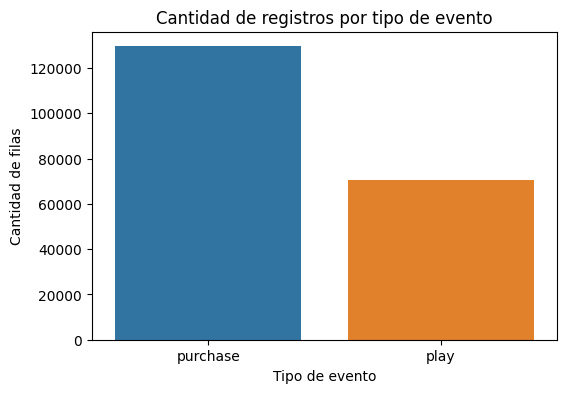

In [69]:
# Cantidad de eventos por tipo (purchase vs play)
plt.figure(figsize=(6, 4))
sns.countplot(data=df1, x="behavior", hue="behavior", legend=False)
plt.title("Cantidad de registros por tipo de evento")
plt.xlabel("Tipo de evento")
plt.ylabel("Cantidad de filas")
plt.show()

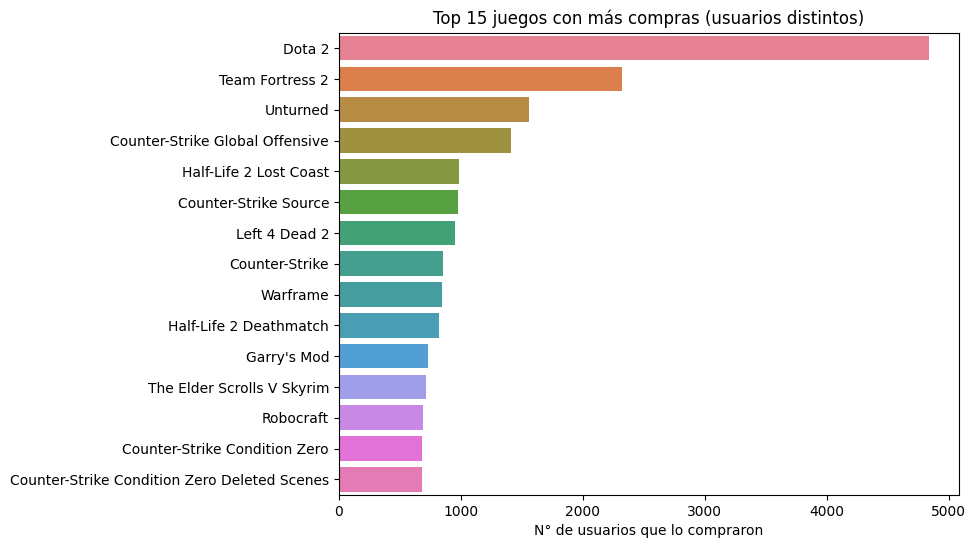

In [70]:
# Top 15 juegos más comprados
top_purchased = (
    df1[df1.behavior == "purchase"]["game"]
    .value_counts()
    .head(15)
)
plt.figure(figsize=(8, 6))
sns.barplot(x=top_purchased.values, y=top_purchased.index, hue=top_purchased.index,
            legend=False)
plt.title("Top 15 juegos con más compras (usuarios distintos)")
plt.xlabel("N° de usuarios que lo compraron")
plt.ylabel("")
plt.show()

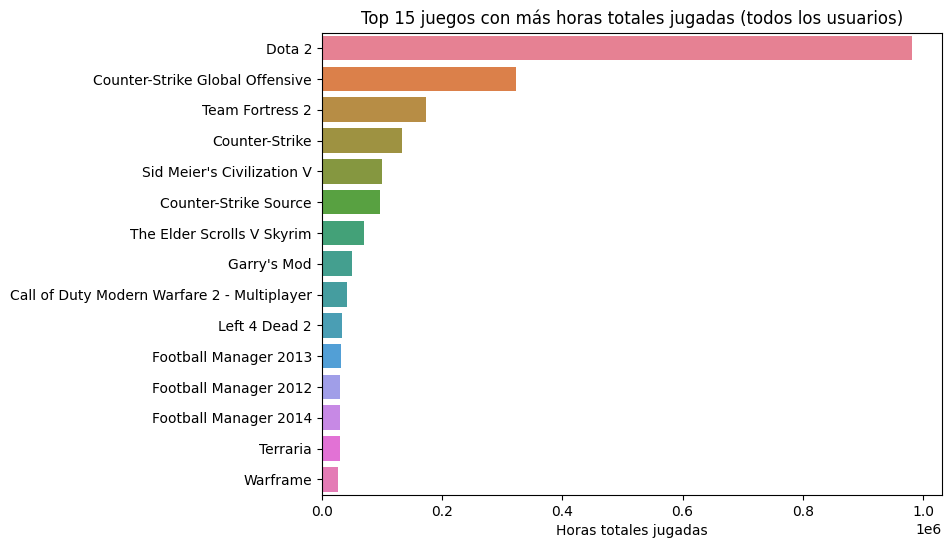

In [71]:
# Top 15 juegos con más horas totales jugadas
top_played = (
    df1[df1.behavior == "play"]
    .groupby("game")["value"].sum()
    .sort_values(ascending=False)
    .head(15)
)
plt.figure(figsize=(8, 6))
sns.barplot(x=top_played.values, y=top_played.index, hue=top_played.index,
             legend=False)
plt.title("Top 15 juegos con más horas totales jugadas (todos los usuarios)")
plt.xlabel("Horas totales jugadas")
plt.ylabel("")
plt.show()

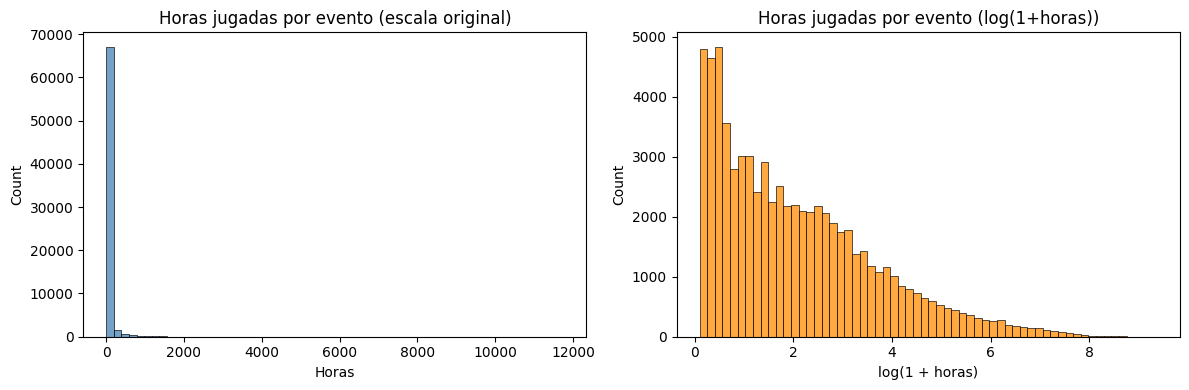

In [72]:
# Distribución de horas jugadas (mucho sesgo, entonces aplicamos log)
horas = df1.loc[df1.behavior == "play", "value"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(horas, bins=60, ax=axes[0], color="steelblue")
axes[0].set_title("Horas jugadas por evento (escala original)")
axes[0].set_xlabel("Horas")

sns.histplot(np.log1p(horas), bins=60, ax=axes[1], color="darkorange")
axes[1].set_title("Horas jugadas por evento (log(1+horas))")
axes[1].set_xlabel("log(1 + horas)")
plt.tight_layout()
plt.show()

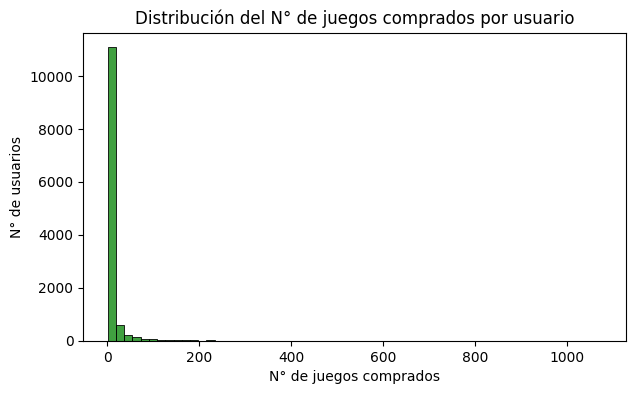

count    12393.000000
mean        10.450335
std         35.864269
min          1.000000
25%          1.000000
50%          2.000000
75%          6.000000
max       1075.000000
Name: game, dtype: float64


In [73]:
# Distribución de la cantidad de juegos comprados por usuario
juegos_por_usuario = df1[df1.behavior == "purchase"].groupby("user_id")["game"].count()

plt.figure(figsize=(7, 4))
sns.histplot(juegos_por_usuario, bins=60, color="green")
plt.title("Distribución del N° de juegos comprados por usuario")
plt.xlabel("N° de juegos comprados")
plt.ylabel("N° de usuarios")
plt.show()

print(juegos_por_usuario.describe())

---
# 2. Preparación de los datos


In [74]:
# Eliminamos la columna irrelevante y los duplicados exactos
df = df1.drop(columns=["extra"])
print("Filas antes de eliminar duplicados:", len(df))
df = df.drop_duplicates()
print("Filas después de eliminar duplicados:", len(df))

Filas antes de eliminar duplicados: 200000
Filas después de eliminar duplicados: 199293


##Transformación a formato usuario–juego

Unimos los registros de purchase y play para cada par (usuario, juego). Si un usuario compró un juego pero nunca aparece jugándolo, le asignamos 0 horas (tenemos que asumir que lo compró y no lo usó).

In [75]:
purchase = df[df.behavior == "purchase"][["user_id", "game"]].drop_duplicates()
play = df[df.behavior == "play"][["user_id", "game", "value"]].drop_duplicates(subset=["user_id", "game"])
play = play.rename(columns={"value": "hours"})

# Unimos: todo lo comprado, con las horas jugadas si existen (si no, 0)
ug = purchase.merge(play, on=["user_id", "game"], how="left")
ug["hours"] = ug["hours"].fillna(0.0)

print(f"Registros usuario-juego: {len(ug):,}")
print(f"Usuarios únicos: {ug.user_id.nunique():,}")
print(f"Juegos únicos: {ug.game.nunique():,}")
ug.head()

Registros usuario-juego: 128,804
Usuarios únicos: 12,393
Juegos únicos: 5,155


,user_id,game,hours
0,151603712,The Elder Scrolls V Skyrim,273.0
1,151603712,Fallout 4,87.0
2,151603712,Spore,14.9
3,151603712,Fallout New Vegas,12.1
4,151603712,Left 4 Dead 2,8.9


## Ingeniería de características

A partir de la tabla usuario–juego construimos variables que describen el **comportamiento agregado** de cada usuario. Estas son las variables candidatas y su justificación de negocio:

| Variable | Descripción | Por qué importa |
|---|---|---|
| `n_games` | N° de juegos distintos comprados | Tamaño de la biblioteca / tendencia coleccionista |
| `total_hours` | Suma de horas jugadas en todos sus juegos | Nivel de compromiso / actividad total |
| `max_hours` | Horas en su juego más jugado | Existencia de un juego "ancla" |
| `n_games_played` | N° de juegos con al menos 1 hora jugada | Amplitud real de uso (no solo compra) |
| `avg_hours_played_game` | Horas promedio, **entre los juegos que sí jugó** | Intensidad de uso cuando juega |
| `pct_played` | % de la biblioteca que efectivamente jugó | Compra "consciente" vs. compra impulsiva/bundle |
| `top_game_share` | % de sus horas totales concentradas en su juego favorito | Especialista (1 juego) vs. explorador (varios) |

No usamos `total_hours` "por juego comprado" (`total_hours / n_games`) como variable principal porque diluye artificialmente a los coleccionistas que compran mucho en ofertas pero juegan pocos títulos; por eso separamos "cuánto juega en lo que sí juega" (`avg_hours_played_game`) de "qué tanto de lo comprado realmente usa" (`pct_played`).

In [76]:
g = ug.groupby("user_id")

feat = pd.DataFrame({
    "n_games": g["game"].count(),
    "total_hours": g["hours"].sum(),
    "max_hours": g["hours"].max(),
    "n_games_played": g.apply(lambda x: (x["hours"] > 0).sum()),
}).reset_index()

feat["avg_hours_played_game"] = (feat["total_hours"] / feat["n_games_played"].replace(0, np.nan)).fillna(0)
feat["pct_played"] = feat["n_games_played"] / feat["n_games"]
feat["top_game_share"] = (feat["max_hours"] / feat["total_hours"].replace(0, np.nan)).fillna(0)

print(f"Usuarios (filas): {feat.shape[0]:,}   Variables: {feat.shape[1]}")
feat.head(10)

Usuarios (filas): 12,393   Variables: 8


/tmp/ipykernel_855/204098294.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  "n_games_played": g.apply(lambda x: (x["hours"] > 0).sum()),


,user_id,n_games,total_hours,max_hours,n_games_played,avg_hours_played_game,pct_played,top_game_share
0,5250,21,225.5,144.0,6,37.583333,0.285714,0.638581
1,76767,36,1227.0,365.0,20,61.350000,0.555556,0.297474
2,86540,82,255.0,113.0,15,17.000000,0.182927,0.443137
3,103360,10,0.0,0.0,0,0.000000,0.000000,0.000000
4,144736,8,0.1,0.1,1,0.100000,0.125000,1.000000
5,181212,12,2.2,1.8,2,1.100000,0.166667,0.818182
6,229911,27,390.5,165.0,18,21.694444,0.666667,0.422535
7,298950,259,3745.4,1019.0,175,21.402286,0.675676,0.272067
8,299153,14,0.0,0.0,0,0.000000,0.000000,0.000000
9,381543,10,3.0,3.0,1,3.000000,0.100000,1.000000


In [77]:
feat.describe().round(2)

,user_id,n_games,total_hours,max_hours,n_games_played,avg_hours_played_game,pct_played,top_game_share
count,1.239300e+04,12393.00,12393.00,12393.00,12393.00,12393.00,12393.00,12393.00
mean,1.611377e+08,10.39,278.01,176.16,5.69,74.32,0.73,0.78
std,8.001490e+07,35.64,760.27,504.76,17.08,283.75,0.34,0.33
min,5.250000e+03,1.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,9.706903e+07,1.00,1.30,1.20,1.00,1.10,0.50,0.60
50%,1.649396e+08,2.00,13.50,11.60,1.00,7.90,1.00,1.00
75%,2.209560e+08,6.00,155.60,107.00,3.00,39.00,1.00,1.00
max,3.099031e+08,1068.00,11754.00,11754.00,498.00,11754.00,1.00,1.00


In [78]:
# Sesgo de las variables numéricas -> justifica la transformación log
cols_numericas = ["n_games", "total_hours", "max_hours", "avg_hours_played_game", "pct_played", "top_game_share"]
feat[cols_numericas].skew().sort_values(ascending=False).round(2)

,0
avg_hours_played_game,15.13
n_games,10.75
max_hours,7.14
total_hours,5.50
pct_played,-0.92
top_game_share,-1.31


n_games, total_hours, max_hours y avg_hours_played_game tienen sesgo muy alto. Unos pocos usuarios concentran cantidades enormes de juegos y horas.

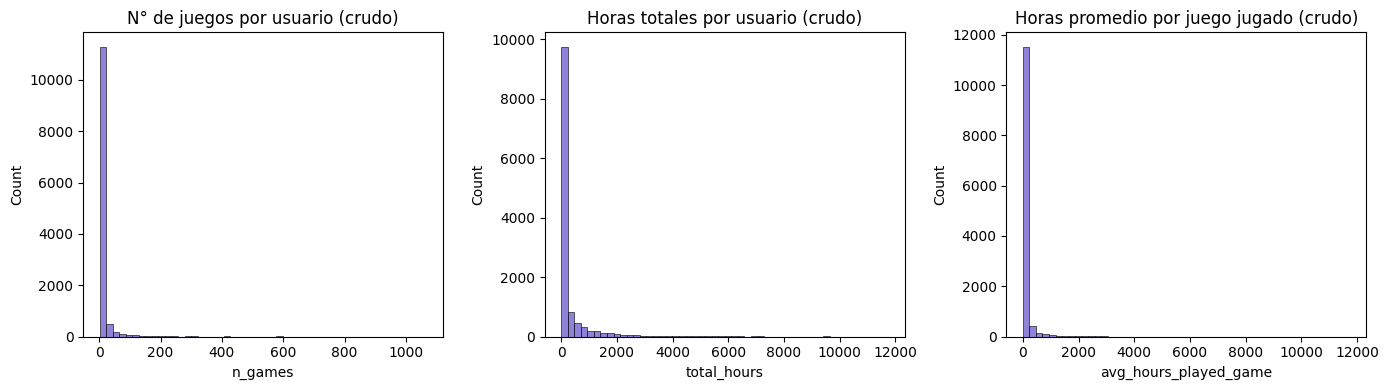

In [79]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.histplot(feat["n_games"], bins=50, ax=axes[0], color="slateblue")
axes[0].set_title("N° de juegos por usuario (crudo)")
sns.histplot(feat["total_hours"], bins=50, ax=axes[1], color="slateblue")
axes[1].set_title("Horas totales por usuario (crudo)")
sns.histplot(feat["avg_hours_played_game"], bins=50, ax=axes[2], color="slateblue")
axes[2].set_title("Horas promedio por juego jugado (crudo)")
plt.tight_layout()
plt.show()

## Selección de variables para clustering

Aquí buscamos evitar redundancias por si acaso. Puede haber variables muy correlacionadas

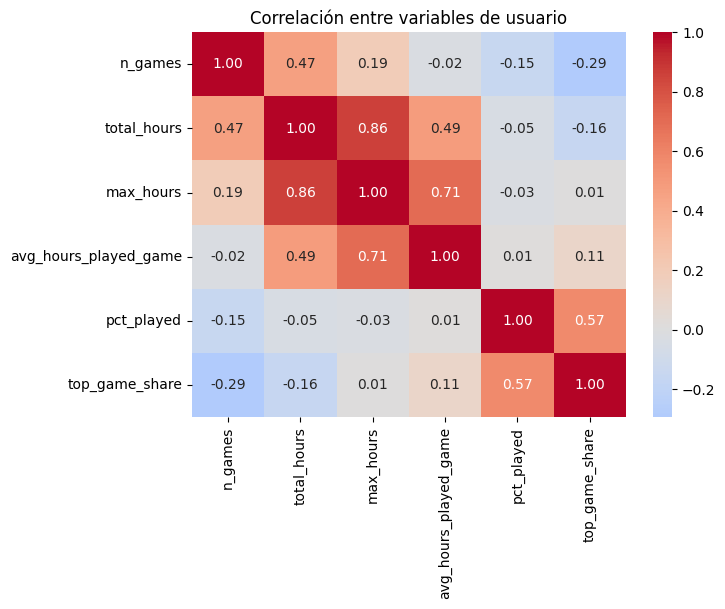

In [80]:
plt.figure(figsize=(7, 5))
corr = feat[cols_numericas].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlación entre variables de usuario")
plt.show()

El set final de variables para el clustering es:

- n_games (tamaño de biblioteca)
- total_hours (compromiso total)
- avg_hours_played_game (intensidad cuando juega)
- pct_played (uso real vs. compra)
- top_game_share (concentración/especialización)

Estas 5 variables cubren sin redundancia las cuatro dimensiones de comportamiento que nos interesan para segmentar: cuánto compra, cuánto juega, qué tan intensamente y qué tan concentrado/disperso es su consumo.

In [81]:
cluster_cols = ["n_games", "total_hours", "avg_hours_played_game", "pct_played", "top_game_share"]
X = feat[cluster_cols].copy()

# Aplicamos log1p SOLO a las variables de conteo/horas (muy sesgadas)
for c in ["n_games", "total_hours", "avg_hours_played_game"]:
    X[c] = np.log1p(X[c])

print("Sesgo luego de log1p:")
print(X.skew().round(2))
X.describe().round(2)

Sesgo luego de log1p:
n_games                  1.61
total_hours              0.43
avg_hours_played_game    0.57
pct_played              -0.92
top_game_share          -1.31
dtype: float64


,n_games,total_hours,avg_hours_played_game,pct_played,top_game_share
count,12393.00,12393.00,12393.00,12393.00,12393.00
mean,1.48,3.07,2.40,0.73,0.78
std,1.06,2.43,1.86,0.34,0.33
min,0.69,0.00,0.00,0.00,0.00
25%,0.69,0.83,0.74,0.50,0.60
50%,1.10,2.67,2.19,1.00,1.00
75%,1.95,5.05,3.69,1.00,1.00
max,6.97,9.37,9.37,1.00,1.00


## Escalamiento

 Si no escalamos, las variables con mayor varianza (como total_hours) dominarían por completo el cálculo de distancia y las proporciones (pct_played, top_game_share) quedarían sin efecto. Usamos StandardScaler para que todas las variables pesen de forma comparable.

In [82]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=cluster_cols)
X_scaled.describe().round(2)

,n_games,total_hours,avg_hours_played_game,pct_played,top_game_share
count,12393.00,12393.00,12393.00,12393.00,12393.00
mean,0.00,-0.00,-0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00
min,-0.74,-1.26,-1.29,-2.11,-2.37
25%,-0.74,-0.92,-0.89,-0.66,-0.55
50%,-0.36,-0.16,-0.11,0.79,0.67
75%,0.44,0.82,0.69,0.79,0.67
max,5.17,2.59,3.75,0.79,0.67


## Reducción de dimensionalidad (PCA)

 Aplicamos PCA a 2 componentes para conservar la mayor parte de la varianza en un espacio más compacto y poder visualizar los clusters resultantes en un plano, igual que se hizo en clase con los datasets sintéticos.

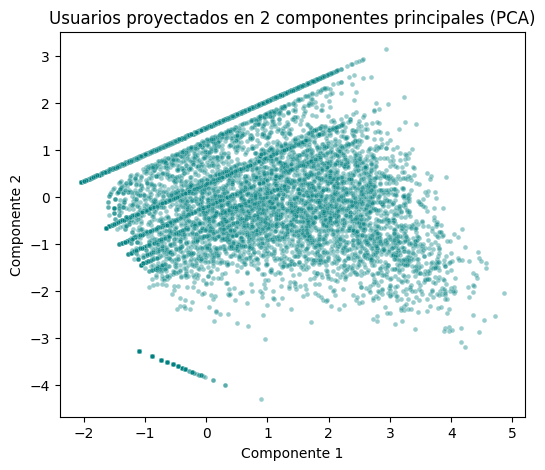

In [83]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)


plt.figure(figsize=(6, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], s=12, alpha=0.4, color="teal")
plt.title("Usuarios proyectados en 2 componentes principales (PCA)")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.show()

Con 2 componentes conservamos cerca del 83% de la varianza total, una reducción razonable que ya deja ver agrupamientos visibles a simple vista, lo cual es un buen indicio para aplicar DBSCAN a continuación.

---
# 3. Modelado: DBSCAN


Elegí **DBSCAN** por tres razones:

1. No conocemos de antemano cuántos "tipos" de jugador existen en los datos; DBSCAN no obliga a fijar ese número.
2. El comportamiento de consumo de videojuegos es heterogéneo y no necesariamente esférico en el espacio de variables (hay usuarios extremos de biblioteca enorme, usuarios de un solo juego, etc.), algo que K-Means tiende a modelar mal porque fuerza fronteras basadas en distancia al centroide.
3. Detectar automáticamente usuarios atípicos como "ruido" es, en sí mismo, valioso para el negocio: en vez de forzar a un usuario con cientos de juegos dentro de un segmento promedio, DBSCAN lo separa explícitamente para que se analice de forma diferenciada.

Para elegir eps: ordenamos, para cada punto, la distancia a su vecino k, y buscamos el "codo" de la curva.

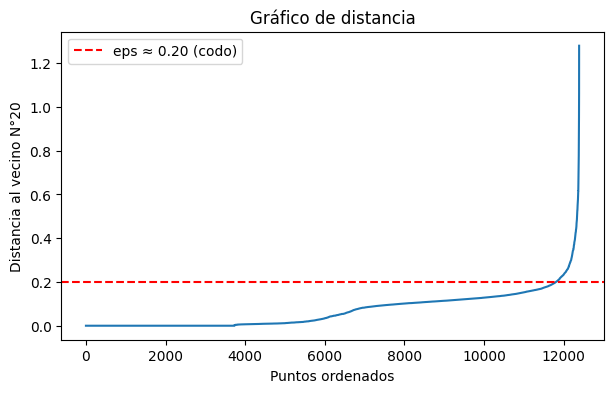

In [84]:
# Método del codo para eps

k = 20  # aprox. 2 x n° de variables usadas en PCA+contexto; se valida abajo junto con eps
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_pca)
distances, _ = neighbors_fit.kneighbors(X_pca)
k_dist = np.sort(distances[:, -1])

plt.figure(figsize=(7, 4))
plt.plot(k_dist)
plt.axhline(0.20, color="red", linestyle="--", label="eps ≈ 0.20 (codo)")
plt.title(f"Gráfico de distancia")
plt.xlabel("Puntos ordenados")
plt.ylabel(f"Distancia al vecino N°{k}")
plt.legend()
plt.show()

El "codo" de la curva se ubica alrededor de 0.20. Confirmamos esta elección explorando combinaciones de eps y min_sample, evaluando N° de clusters, % de ruido y silhouette score (excluyendo el ruido, ya que este último no forma parte de ningún cluster).

In [85]:
resultados = []
for eps in [0.15, 0.18, 0.20, 0.25, 0.30]:
    for ms in [10, 15, 20, 25, 30]:
        labels_tmp = DBSCAN(eps=eps, min_samples=ms).fit_predict(X_pca)
        n_clusters = len(set(labels_tmp)) - (1 if -1 in labels_tmp else 0)
        ruido_pct = (labels_tmp == -1).mean() * 100
        if n_clusters >= 2:
            mask = labels_tmp != -1
            sil = silhouette_score(X_pca[mask], labels_tmp[mask])
        else:
            sil = np.nan
        resultados.append([eps, ms, n_clusters, round(ruido_pct, 1), round(sil, 3) if sil == sil else None])

tabla_resultados = pd.DataFrame(resultados, columns=["eps", "min_samples", "n_clusters", "% ruido", "silhouette"])
tabla_resultados.sort_values(["n_clusters", "silhouette"], ascending=[False, False]).head(12)

,eps,min_samples,n_clusters,% ruido,silhouette
0,0.15,10,9,2.2,0.277
4,0.15,30,9,13.1,0.031
3,0.15,25,9,9.2,-0.218
2,0.15,20,8,6.1,0.100
1,0.15,15,6,4.1,0.266
12,0.20,20,5,2.7,0.313
14,0.20,30,5,4.6,0.305
10,0.20,10,5,1.2,0.250
5,0.18,10,5,1.3,0.247
11,0.20,15,5,1.6,0.245


La combinación eps = 0.2, min_samples = 20 ofrece un buen equilibrio: genera 5 clusters interpretables y demás factores que lo hacen propicio para este ejercicio.

In [86]:
# Modelo final
dbscan = DBSCAN(eps=0.20, min_samples=20)
labels = dbscan.fit_predict(X_pca)

feat["cluster"] = labels
feat["pca1"] = X_pca[:, 0]
feat["pca2"] = X_pca[:, 1]

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_ruido = (labels == -1).sum()

print(f"N° de clusters encontrados: {n_clusters}")
print(f"Usuarios marcados como ruido/outliers: {n_ruido} ({n_ruido/len(labels)*100:.2f}%)")

mask = labels != -1
sil = silhouette_score(X_pca[mask], labels[mask])
print(f"Silhouette score (excluyendo ruido): {sil:.3f}")

feat["cluster"].value_counts().sort_index()

N° de clusters encontrados: 5
Usuarios marcados como ruido/outliers: 340 (2.74%)
Silhouette score (excluyendo ruido): 0.313


,count
cluster,
-1,340
0,5877
1,465
2,18
3,5120
4,573


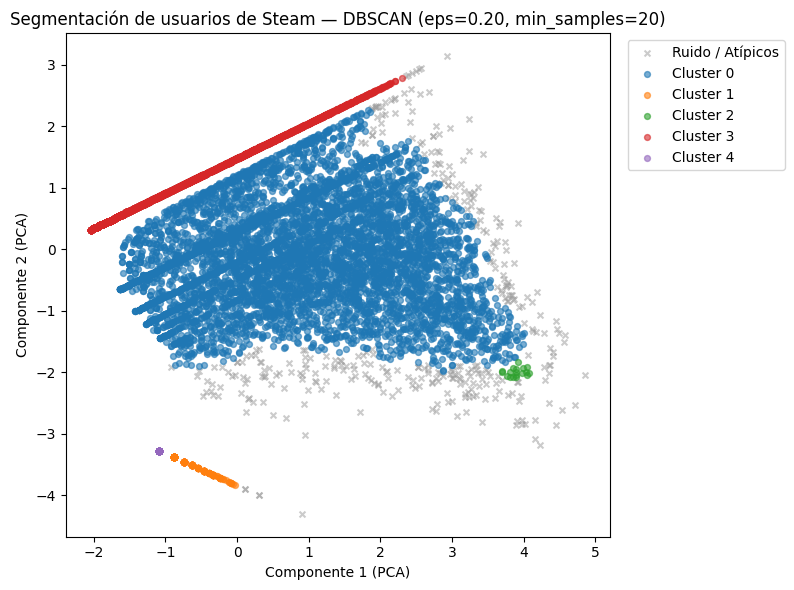

In [87]:
# Visualización final de los clusters sobre el plano PCA
plt.figure(figsize=(8, 6))
paleta = sns.color_palette("tab10", n_colors=n_clusters)
colores = {i: paleta[i] for i in range(n_clusters)}
colores[-1] = (0.6, 0.6, 0.6)  # gris para el ruido

for cl in sorted(feat["cluster"].unique()):
    sub = feat[feat.cluster == cl]
    label = "Ruido / Atípicos" if cl == -1 else f"Cluster {cl}"
    marker = "x" if cl == -1 else "o"
    plt.scatter(sub["pca1"], sub["pca2"], s=18, alpha=0.6 if cl != -1 else 0.5,
                color=colores[cl], label=label, marker=marker)

plt.title("Segmentación de usuarios de Steam — DBSCAN (eps=0.20, min_samples=20)")
plt.xlabel("Componente 1 (PCA)")
plt.ylabel("Componente 2 (PCA)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

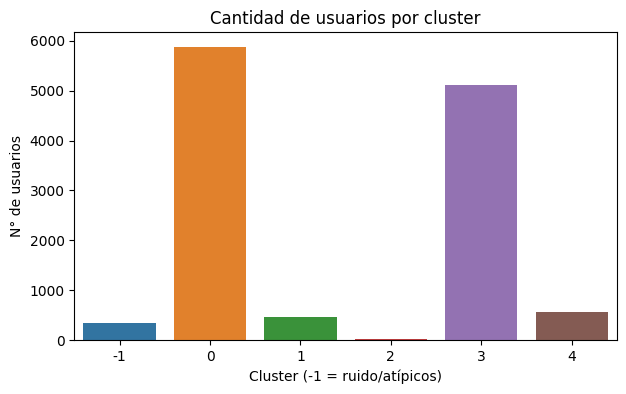

In [88]:
# Tamaño de cada cluster
plt.figure(figsize=(7, 4))
orden = feat["cluster"].value_counts().sort_index().index
sns.countplot(data=feat, x="cluster", order=orden, hue="cluster", palette="tab10", legend=False)
plt.title("Cantidad de usuarios por cluster")
plt.xlabel("Cluster (-1 = ruido/atípicos)")
plt.ylabel("N° de usuarios")
plt.show()

---
# 4. Interpretación de los clusters

Para caracterizar a cada grupo, calculamos estadísticos (media y mediana) de las variables originales antes de transformar y escalar por cluster. Usamos la mediana como referencia principal.

In [89]:
perfil = feat.groupby("cluster").agg(
    n_usuarios=("user_id", "count"),
    n_games_mediana=("n_games", "median"),
    n_games_media=("n_games", "mean"),
    total_hours_mediana=("total_hours", "median"),
    total_hours_media=("total_hours", "mean"),
    n_games_played_mediana=("n_games_played", "median"),
    pct_played_media=("pct_played", "mean"),
    avg_hours_played_game_mediana=("avg_hours_played_game", "median"),
    top_game_share_media=("top_game_share", "mean"),
).round(2)
perfil["% del total"] = (perfil["n_usuarios"] / len(feat) * 100).round(2)
perfil

,n_usuarios,n_games_mediana,n_games_media,total_hours_mediana,total_hours_media,n_games_played_mediana,pct_played_media,avg_hours_played_game_mediana,top_game_share_media,% del total
cluster,,,,,,,,,,
-1,340,36.0,98.76,1103.55,2276.62,14.0,0.48,16.14,0.49,2.74
0,5877,5.0,13.99,82.00,389.85,3.0,0.63,19.70,0.74,47.42
1,465,3.0,3.92,0.00,0.00,0.0,0.00,0.00,0.00,3.75
2,18,287.5,304.17,2565.10,2486.53,153.0,0.51,15.78,0.19,0.15
3,5120,1.0,1.00,3.70,65.50,1.0,1.00,3.70,1.00,41.31
4,573,1.0,1.00,0.00,0.00,0.0,0.00,0.00,0.00,4.62


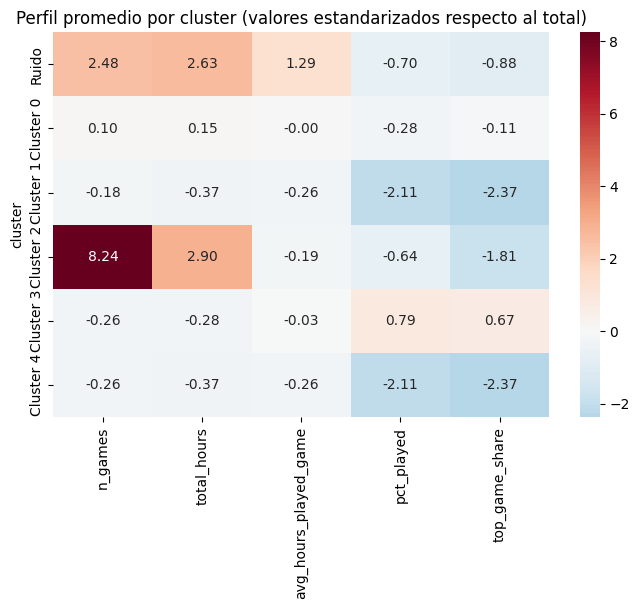

In [90]:
# Comparamos clusters a simple vista
perfil_z = feat.groupby("cluster")[cluster_cols].mean()
perfil_z_scaled = (perfil_z - feat[cluster_cols].mean()) / feat[cluster_cols].std()

plt.figure(figsize=(8, 5))
sns.heatmap(perfil_z_scaled, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            yticklabels=[f"Cluster {i}" if i != -1 else "Ruido" for i in perfil_z_scaled.index])
plt.title("Perfil promedio por cluster (valores estandarizados respecto al total)")
plt.xlabel("")
plt.show()

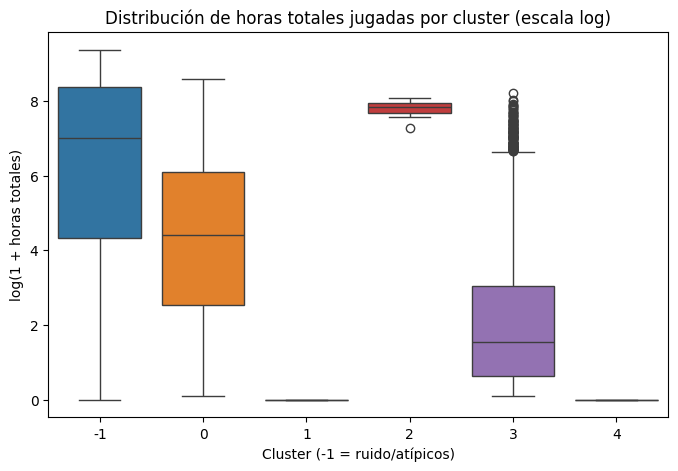

In [91]:
# Comparación de horas totales jugadas por cluster (escala log para que sea legible)
plt.figure(figsize=(8, 5))
orden_cl = sorted(feat["cluster"].unique())
sns.boxplot(data=feat, x="cluster", y=np.log1p(feat["total_hours"]), order=orden_cl,
            hue="cluster", palette="tab10", legend=False)
plt.title("Distribución de horas totales jugadas por cluster (escala log)")
plt.xlabel("Cluster (-1 = ruido/atípicos)")
plt.ylabel("log(1 + horas totales)")
plt.show()

## Descripción de cada segmento

Cluster 0 — (≈47% de los usuarios)
Biblioteca moderada (mediana de 5 juegos), de los cuales efectivamente juegan una buena parte (~63% en promedio). Concentran la mayoría de su tiempo en 1-2 juegos favoritos (top_game_share ≈ 0.74) y acumulan un gran uso (mediana de 82 horas totales). Son jugadores frecuentes, no ocasionales: compran con criterio y le dan uso real a lo que compran.

Cluster 1 — (≈3.8%)
Compraron en promedio 4 juegos, pero 0 horas jugadas en todos los casos (pct_played = 0). Es un grupo que adquiere juegos (probablemente en ofertas o bundles) pero nunca los abre. No son jugadores activos.

Cluster 2 — (≈0.15%, 18 usuarios)
El grupo más pequeño pero más extremo: mediana de 287 juegos comprados, 153 efectivamente jugados y más de 2,500 horas acumuladas.

Cluster 3 — (≈41%)
Compraron exactamente 1 juego y le dedicaron algo de tiempo (mediana 3.7 horas, aunque existe un subgrupo minoritario con miles de horas en ese único título, típico de jugadores de un solo juego competitivo). Es el segundo grupo más grande del dataset: usuarios de bajo compromiso con la plataforma en términos de catálogo, pero que sí usan lo que tienen.

Cluster 4 — (≈4.6%)
Compraron 1 solo juego y nunca lo jugaron (0 horas). Similar al Cluster 1 pero con biblioteca mínima — probablemente compras impulsivas, regalos o adquisiciones que nunca despertaron interés real.

Ruido (≈2.7%, etiqueta -1)
Usuarios que no encajan en ningún patrón denso: combinaciones inusuales de biblioteca grande + consumo medio-alto que no forman un grupo compacto. DBSCAN los deja fuera de los clusters porque su comportamiento es demasiado disperso/individual como para generalizarlo — son candidatos a análisis caso por caso, no a campañas masivas.

---
# 5. Recomendaciones de negocio


Aplicamos según el grupo de clientes.

**Cluster 0** | 47.4% | Recomendaciones personalizadas basadas en su juego favorito; contenido descargable de los títulos que ya juegan | Descuentos en secuelas/DLC de sus juegos favoritos; bundles temáticos por género.

Las campañas de fidelización deben ser altas. Son la base más grande y ya demuestran compromiso real, es el segmento con mejor retorno esperado.

**Cluster 1**  | 3.8% | Campañas de reactivación: recordatorios de lo que ya compraron, tutoriales de inicio rápido, etc | Nada de descuentos adicionales (ya compraron) y notificaciones para activar el uso.

Las campañas de fidelización deben ser medias. Hay que busacr que activen lo que ya tienen en vez de que compren más.

**Cluster 2** | 0.15% | Trato VIP: acceso anticipado , betas exclusivas, contacto directo/comunidad | Bundles grandes, ediciones coleccionista, ofertas por volumen.

Los esfuerzos de retención y fidelización deben ser muy altos. Son pocos pero de altísimo valor y engagement; ideales para programas de embajadores o afiliados.

**Cluster 3**  | 41.3% | Mostrarles juegos similares al único que tienen para ampliar su catálogo | Descuentos de entrada baja en juegos del mismo género que su único juego.

Es el segmento con mayor potencial de crecimiento (de 1 a 2+ juegos) por su tamaño.

**Cluster 4**  | 4.6% | Recordarles que tienen el juego, tutoriales, eventos in-game | Evitar más descuentos; enfocar en activación, no en venta.

Tienen bajo compromiso demostrado. Primero activar antes de invertir en fidelización.

**Ruido** | 2.7% | Revisión manual / analítica caso por caso antes de incluir en campañas masivas | No aplican promociones estándar.

**Priorización general para campañas de fidelización:** El Cluster 2 tiene un altísimo valor por usuario aunque son pocos, luego los del Cluster 0, que tienen mayor volumen con compromiso real, y en tercer lugar los del Cluster 3 por su tamaño y potencial de crecimiento. Los compradores del Clusters 1 y 4 deberían recibir esfuerzos de activación antes que de venta, ya que ofrecerles más descuentos sin haber usado lo que ya compraron tiene bajo retorno esperado.

## ¿Qué información adicional mejoraría la segmentación?

- Fecha/timestamp de compra y de sesiones de juego, para medir cuándo jugó por última vez y no solo volumen acumulado — hoy no podemos distinguir a un usuario activo la semana pasada de uno inactivo hace 2 años.
- Gasto real en dinero(precio pagado, no solo si compró o no), para segmentar también por valor monetario y no solo por comportamiento de uso.
- Género/categoría de cada juego (acción, estrategia, deportes, etc.), para enriquecer el perfil con *preferencias temáticas* y no solo métricas de intensidad.
- Plataforma/dispositivo y datos demográficos (edad, país), útiles para targeting geográfico y de producto.
- Señales sociales: uso de funciones multijugador, amigos en común, participación en comunidades — importante para campañas de referidos.
- Historial de reseñas/calificaciones dejadas por el usuario, como proxy de satisfacción.

## Conclusión

DBSCAN permitió identificar 5 segmentos de usuarios bien diferenciados (más un grupo de atípicos) a partir únicamente del comportamiento de compra y consumo, sin necesidad de fijar de antemano el número de grupos. La segmentación resultante es clara y accionable: distingue con nitidez entre usuarios que compran vs. que efectivamente usan lo comprado, y entre consumo concentrado vs. disperso, lo cual entrega una base sólida para diseñar estrategias diferenciadas de marketing y fidelización.